In [1]:
# ================================
# 1. IMPORT LIBRARIES
# ================================

import pandas as pd        # Data read aur analyze karne ke liye

import numpy as np         # Fast calculations aur arrays ke liye

import matplotlib.pyplot as plt    # Graphs aur charts banane ke liye

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ================================
# 2. LOAD DATASET
# ================================

df = pd.read_csv("ai-requirements-index.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully!
Shape: (2169, 8)


,snapshot_date,category,seniority,tier,listings_with_ai,total_listings,pct,required_count
0,12-03-2026,ai,all,any_ai,253,266,95.1,253
1,12-03-2026,ai,all,genai,210,266,78.9,207
2,12-03-2026,ai,all,ml,186,266,69.9,186
3,12-03-2026,ai,entry,any_ai,1,1,100.0,1
4,12-03-2026,ai,entry,genai,1,1,100.0,1


In [3]:
# ================================
# 3. BASIC DATASET INFORMATION
# ================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Rows: 2169
Columns: 8

Column Names:
['snapshot_date', 'category', 'seniority', 'tier', 'listings_with_ai', 'total_listings', 'pct', 'required_count']

Data Types:
snapshot_date           str
category                str
seniority               str
tier                    str
listings_with_ai      int64
total_listings        int64
pct                 float64
required_count        int64
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2169 entries, 0 to 2168
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   snapshot_date     2169 non-null   str    
 1   category          2169 non-null   str    
 2   seniority         2169 non-null   str    
 3   tier              2169 non-null   str    
 4   listings_with_ai  2169 non-null   int64  
 5   total_listings    2169 non-null   int64  
 6   pct               2169 non-null   float64
 7   required_count    2169 non-null   int64  
dtypes: flo

In [4]:
# ================================
# 4. STATISTICAL SUMMARY
# ================================

df.describe()

,listings_with_ai,total_listings,pct,required_count
count,2169.000000,2169.000000,2169.000000,2169.000000
mean,117.789765,1059.654219,19.195067,114.292301
std,190.608186,1807.026455,22.609884,187.437725
min,0.000000,1.000000,0.000000,0.000000
25%,6.000000,77.000000,2.900000,5.000000
50%,42.000000,265.000000,11.200000,40.000000
75%,142.000000,1239.000000,26.100000,138.000000
max,1444.000000,11337.000000,100.000000,1438.000000


In [35]:
# ================================
# 5. MISSING VALUE CHECK
# ================================

missing_values = df.isnull().sum()


print("\nTotal Missing Values:", missing_values.sum())


Total Missing Values: 0


In [6]:
# ================================
# 6. DUPLICATE CHECK
# ================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
# ================================
# 7. DATA CLEANING
# ================================

# Remove duplicate rows
df = df.drop_duplicates()

# Convert date column
df["snapshot_date"] = pd.to_datetime(
    df["snapshot_date"],
    dayfirst=True,
    errors="coerce"
)

# Remove rows where important values are missing
df = df.dropna(
    subset=[
        "category",
        "seniority",
        "tier",
        "listings_with_ai",
        "total_listings",
        "pct",
        "required_count"
    ]
)

# Make sure numeric columns are numeric
numeric_columns = [
    "listings_with_ai",
    "total_listings",
    "pct",
    "required_count"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove invalid numeric rows
df = df.dropna(subset=numeric_columns)

print("Cleaned Dataset Shape:", df.shape)
print("Remaining Missing Values:", df.isnull().sum().sum())

Cleaned Dataset Shape: (2169, 8)
Remaining Missing Values: 0


In [40]:
# ================================
# 8. CREATE DATE FEATURES
# ================================

df["year"] = df["snapshot_date"].dt.year
df["month"] = df["snapshot_date"].dt.month
df["day"] = df["snapshot_date"].dt.day

df.head()

,snapshot_date,category,seniority,tier,listings_with_ai,total_listings,pct,required_count,year,month,day,ai_requirement_class
0,2026-03-12,ai,all,any_ai,253,266,95.1,253,2026,3,12,1
1,2026-03-12,ai,all,genai,210,266,78.9,207,2026,3,12,1
2,2026-03-12,ai,all,ml,186,266,69.9,186,2026,3,12,1
3,2026-03-12,ai,entry,any_ai,1,1,100.0,1,2026,3,12,1
4,2026-03-12,ai,entry,genai,1,1,100.0,1,2026,3,12,1


In [41]:
# ================================
# 9. UNIQUE VALUES
# ================================

df["category"].unique()

<StringArray>
['ai', 'data', 'devops', 'engineering', 'product', 'security']
Length: 6, dtype: str

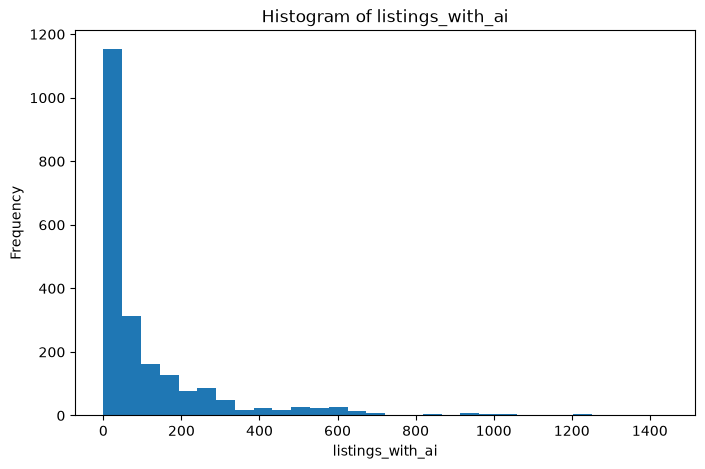

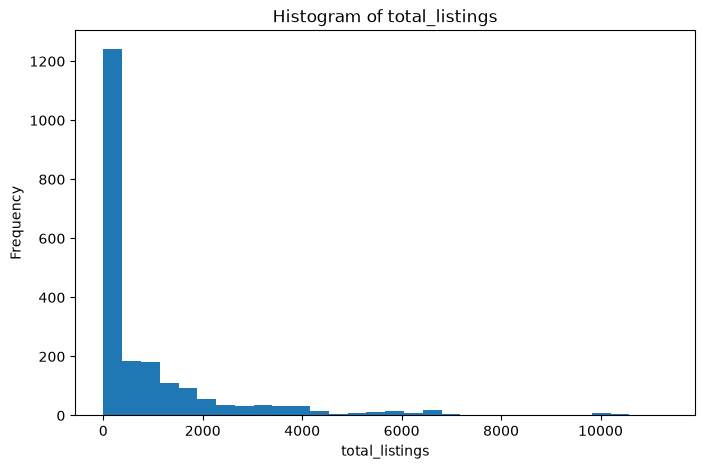

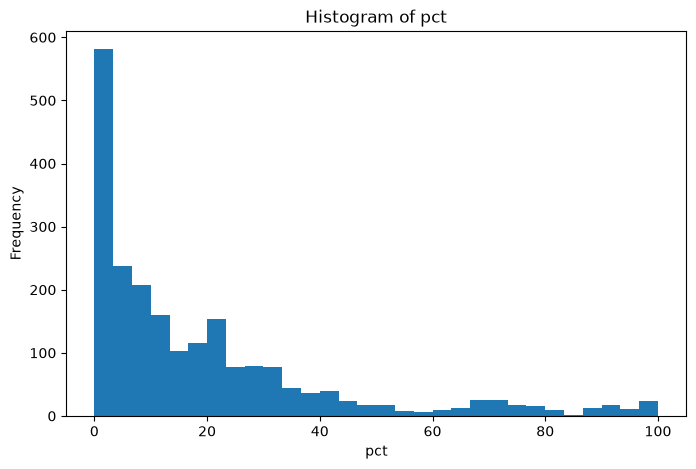

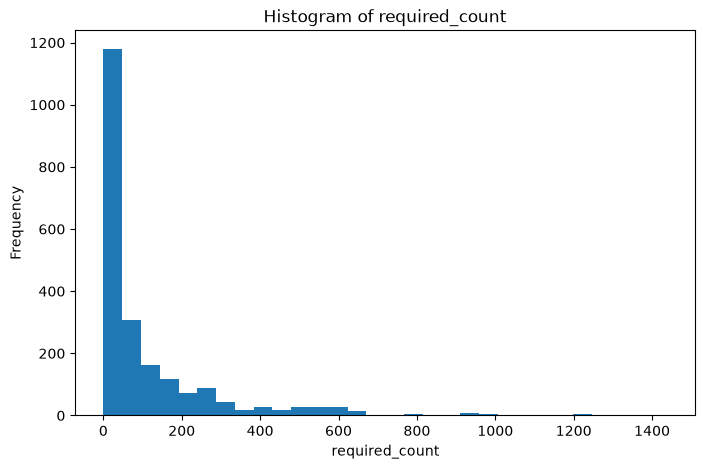

In [10]:
# ================================
# 10. HISTOGRAMS
# ================================

numeric_cols = [
    "listings_with_ai",
    "total_listings",
    "pct",
    "required_count"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

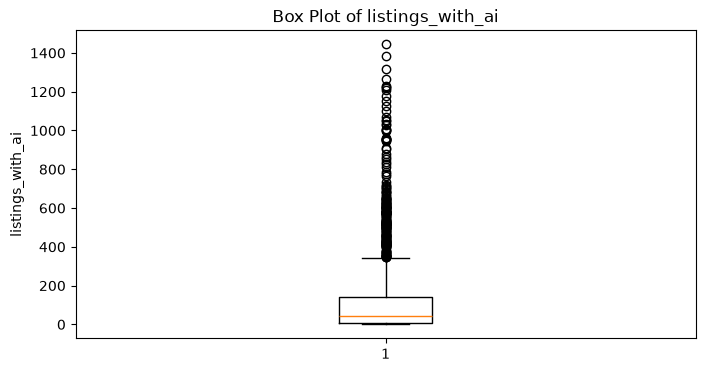

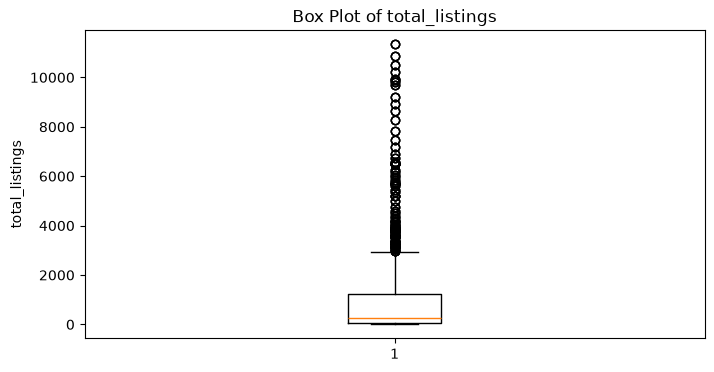

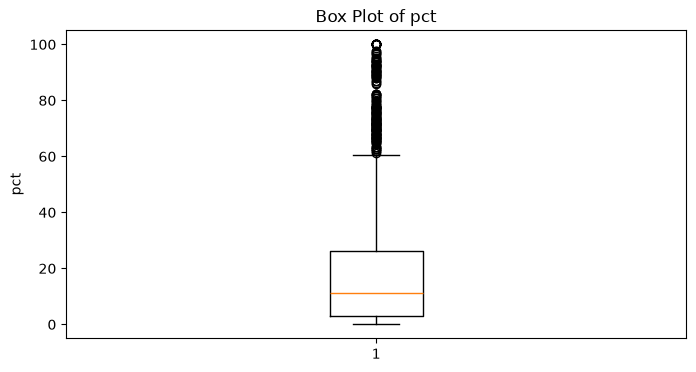

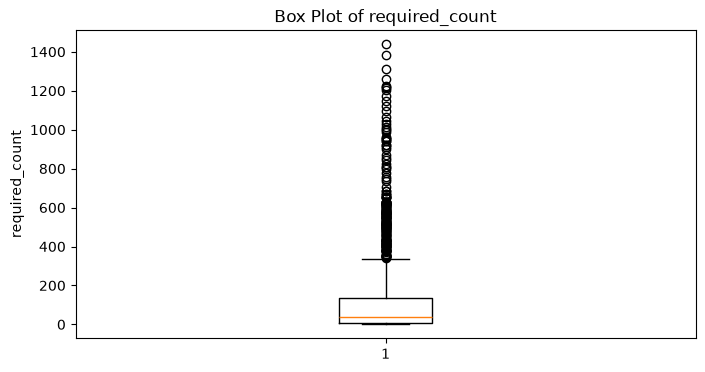

In [ ]:
# ================================
# 11. BOX PLOTS
# ================================

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col])
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col) 
    plt.show()

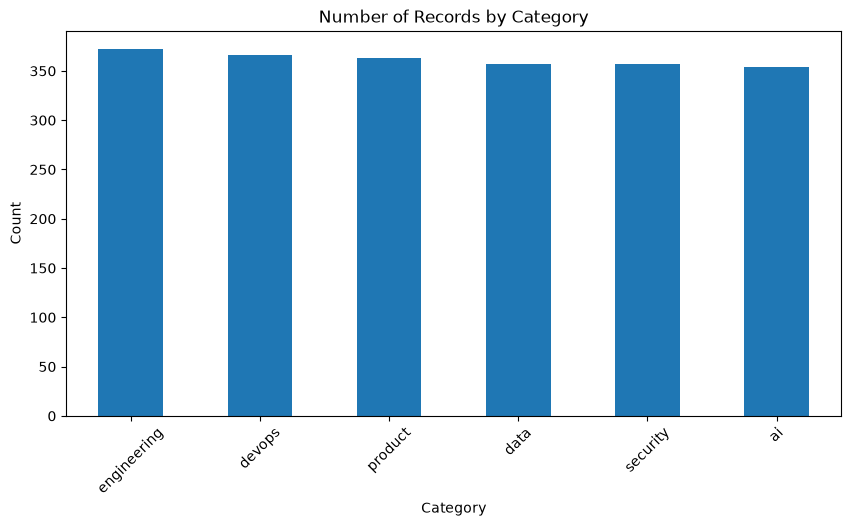

In [12]:
# ================================
# 12. CATEGORY DISTRIBUTION
# ================================

plt.figure(figsize=(10, 5))

df["category"].value_counts().plot(kind="bar")

plt.title("Number of Records by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

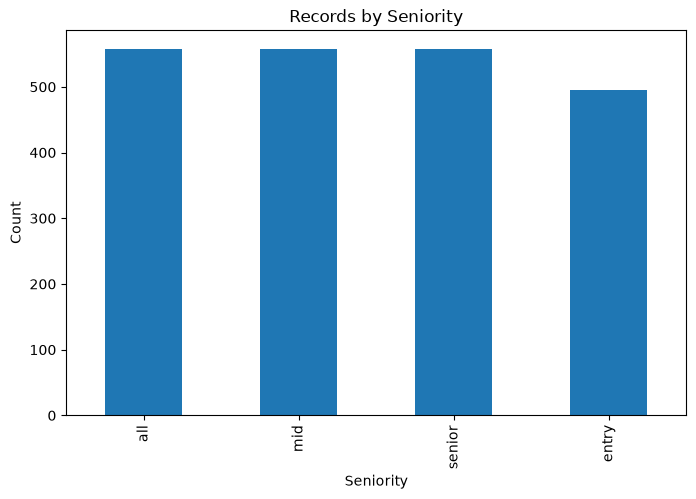

In [13]:
# ================================
# 13. SENIORITY DISTRIBUTION
# ================================

plt.figure(figsize=(8, 5))

df["seniority"].value_counts().plot(kind="bar")

plt.title("Records by Seniority")
plt.xlabel("Seniority")
plt.ylabel("Count")
plt.show()

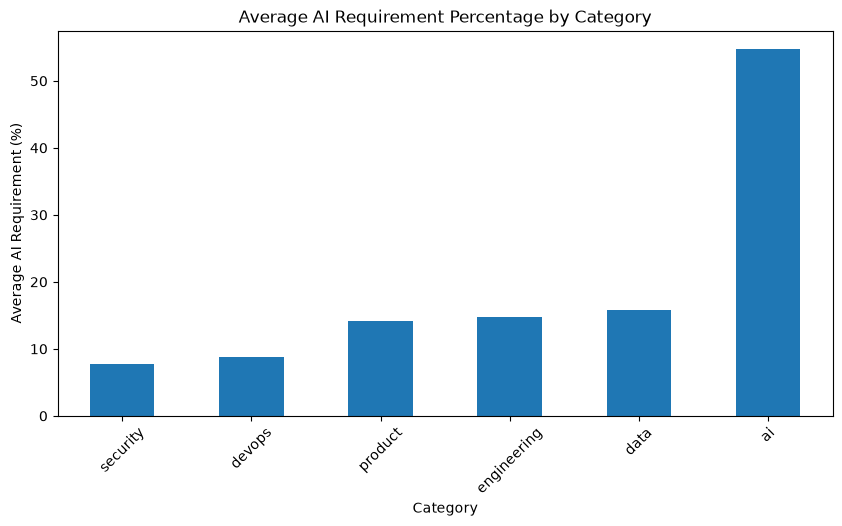

In [14]:
# ================================
# 14. AI REQUIREMENT BY CATEGORY
# ================================

category_pct = df.groupby("category")["pct"].mean().sort_values()

plt.figure(figsize=(10, 5))

category_pct.plot(kind="bar")

plt.title("Average AI Requirement Percentage by Category")
plt.xlabel("Category")
plt.ylabel("Average AI Requirement (%)")
plt.xticks(rotation=45)
plt.show()

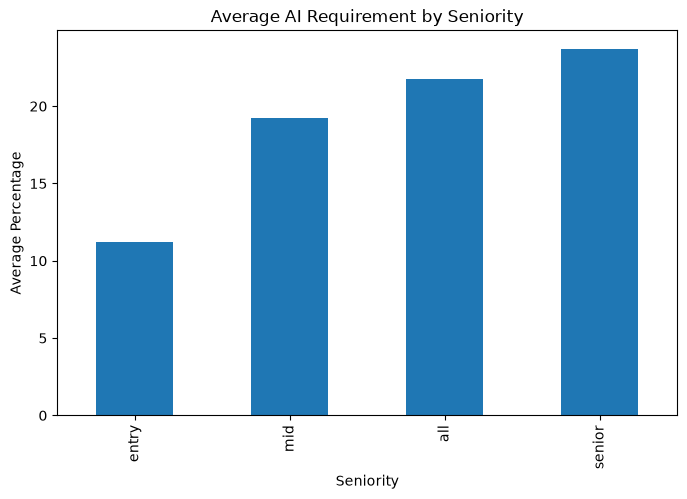

In [15]:
# ================================
# 15. AI REQUIREMENT BY SENIORITY
# ================================

seniority_pct = df.groupby("seniority")["pct"].mean().sort_values()

plt.figure(figsize=(8, 5))

seniority_pct.plot(kind="bar")

plt.title("Average AI Requirement by Seniority")
plt.xlabel("Seniority")
plt.ylabel("Average Percentage")
plt.show()

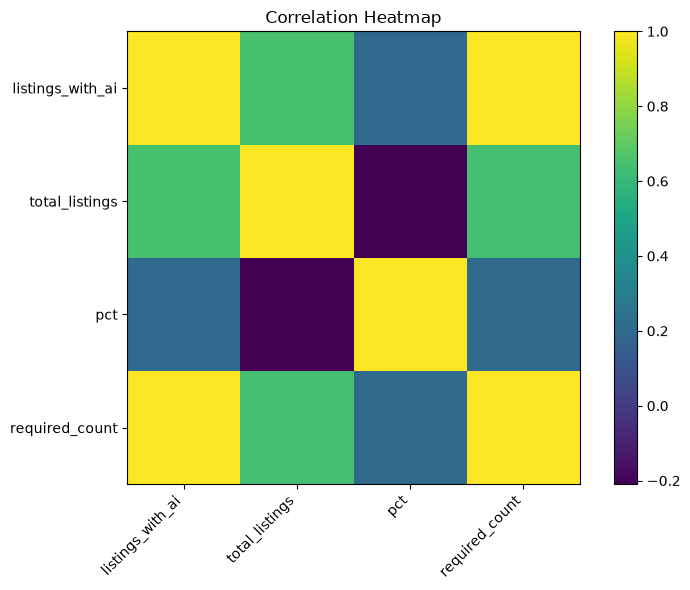

In [16]:
# ================================
# 16. CORRELATION HEATMAP
# ================================

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr, interpolation="nearest")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [17]:
# ================================
# 17. LINEAR REGRESSION DATA
# ================================

X = df[
    [
        "category",
        "seniority",
        "tier",
        "listings_with_ai",
        "total_listings",
        "required_count",
        "year",
        "month",
        "day"
    ]
]

y = df["pct"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

categorical_features = [
    "category",
    "seniority",
    "tier"
]

numeric_features = [
    "listings_with_ai",
    "total_listings",
    "required_count",
    "year",
    "month",
    "day"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [18]:
# ================================
# 18. LINEAR REGRESSION
# ================================

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("Linear Regression Results")
print("-------------------------")

print("MAE:", mean_absolute_error(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

print("R² Score:", r2_score(y_test, y_pred))

Linear Regression Results
-------------------------
MAE: 7.510012838777621
RMSE: 10.615853089570102
R² Score: 0.7934307925342091


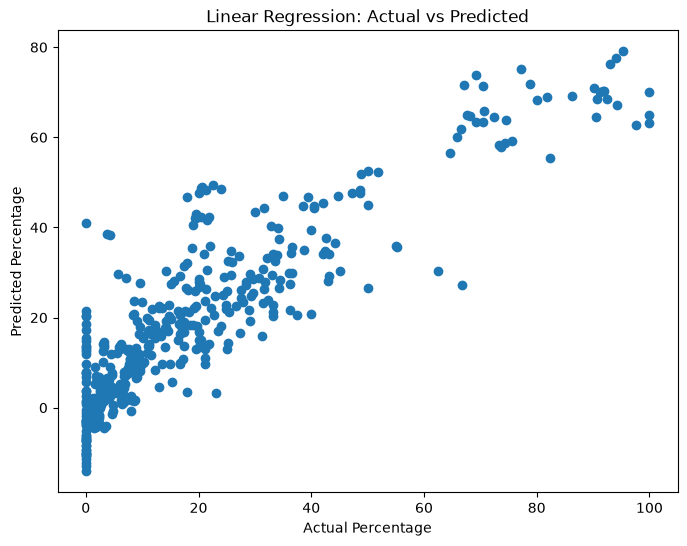

In [19]:
# ================================
# 19. ACTUAL VS PREDICTED
# ================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Percentage")
plt.ylabel("Predicted Percentage")

plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [20]:
# ================================
# 20. CREATE CLASSIFICATION TARGET
# ================================

threshold = df["pct"].median()

df["ai_requirement_class"] = (
    df["pct"] >= threshold
).astype(int)

print("Median Threshold:", threshold)

print("\nClass Distribution:")
print(df["ai_requirement_class"].value_counts())

Median Threshold: 11.2

Class Distribution:
ai_requirement_class
1    1088
0    1081
Name: count, dtype: int64


In [21]:
# ================================
# 21. CLASSIFICATION DATA
# ================================

X = df[
    [
        "category",
        "seniority",
        "tier",
        "listings_with_ai",
        "total_listings",
        "required_count",
        "year",
        "month",
        "day"
    ]
]

y = df["ai_requirement_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [22]:
# ================================
# 22. DECISION TREE - GINI INDEX
# ================================

dt_gini = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "model",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=5,
                random_state=42
            )
        )
    ]
)

dt_gini.fit(X_train, y_train)

y_pred_gini = dt_gini.predict(X_test)

print("DECISION TREE - GINI")
print("--------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred_gini))

print("Precision:",
      precision_score(y_test, y_pred_gini))

print("Recall:",
      recall_score(y_test, y_pred_gini))

print("F1 Score:",
      f1_score(y_test, y_pred_gini))

DECISION TREE - GINI
--------------------
Accuracy: 0.9377880184331797
Precision: 0.9098712446351931
Recall: 0.9724770642201835
F1 Score: 0.9401330376940134


In [23]:
# ================================
# 23. DECISION TREE - ENTROPY
# ================================

dt_entropy = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "model",
            DecisionTreeClassifier(
                criterion="entropy",
                max_depth=5,
                random_state=42
            )
        )
    ]
)

dt_entropy.fit(X_train, y_train)

y_pred_entropy = dt_entropy.predict(X_test)

print("DECISION TREE - ENTROPY")
print("-----------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred_entropy))

print("Precision:",
      precision_score(y_test, y_pred_entropy))

print("Recall:",
      recall_score(y_test, y_pred_entropy))

print("F1 Score:",
      f1_score(y_test, y_pred_entropy))

DECISION TREE - ENTROPY
-----------------------
Accuracy: 0.9308755760368663
Precision: 0.9122807017543859
Recall: 0.9541284403669725
F1 Score: 0.9327354260089686


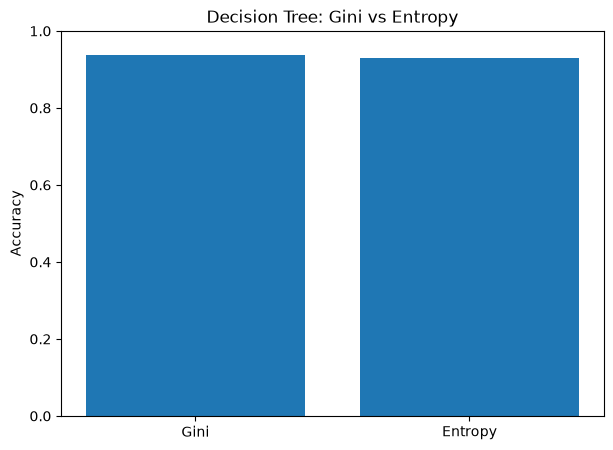

In [24]:
# ================================
# 24. GINI VS ENTROPY
# ================================

gini_accuracy = accuracy_score(y_test, y_pred_gini)
entropy_accuracy = accuracy_score(y_test, y_pred_entropy)

models = ["Gini", "Entropy"]
scores = [gini_accuracy, entropy_accuracy]

plt.figure(figsize=(7, 5))

plt.bar(models, scores)

plt.title("Decision Tree: Gini vs Entropy")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

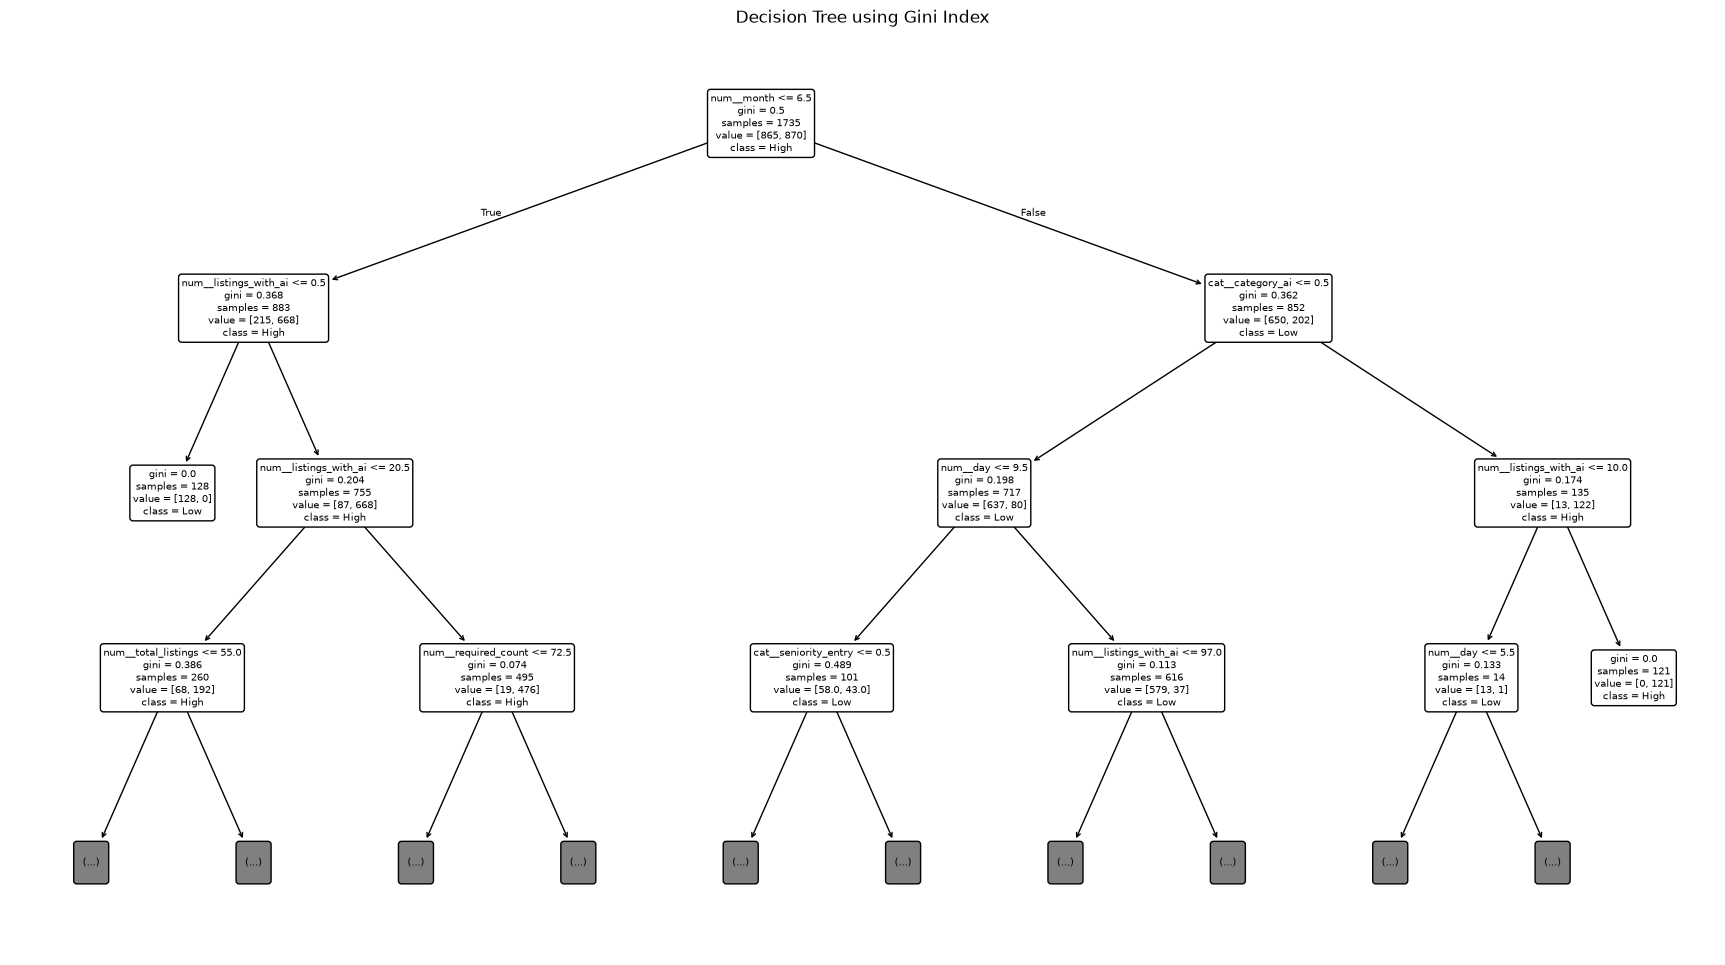

In [25]:
# ================================
# 25. DECISION TREE VISUALIZATION
# ================================

tree_model = dt_gini.named_steps["model"]

feature_names = (
    dt_gini.named_steps["preprocessor"]
    .get_feature_names_out()
)

plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Low", "High"],
    filled=False,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree using Gini Index")

plt.show()

In [26]:
# ================================
# 26. RANDOM FOREST
# ================================

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=8,
                random_state=42
            )
        )
    ]
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

print("RANDOM FOREST RESULTS")
print("---------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

RANDOM FOREST RESULTS
---------------------
Accuracy: 0.9723502304147466
Precision: 0.9557522123893806
Recall: 0.9908256880733946
F1 Score: 0.972972972972973


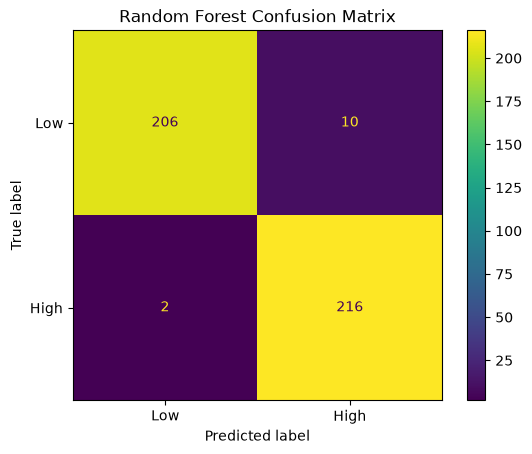

In [27]:
# ================================
# 27. CONFUSION MATRIX
# ================================

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "High"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [28]:
# ================================
# 28. CLASSIFICATION REPORT
# ================================

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Low", "High"]
    )
)

              precision    recall  f1-score   support

         Low       0.99      0.95      0.97       216
        High       0.96      0.99      0.97       218

    accuracy                           0.97       434
   macro avg       0.97      0.97      0.97       434
weighted avg       0.97      0.97      0.97       434



In [29]:
# ================================
# 29. MODEL COMPARISON
# ================================

results = pd.DataFrame({
    "Model": [
        "Decision Tree - Gini",
        "Decision Tree - Entropy",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_gini),
        accuracy_score(y_test, y_pred_entropy),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_gini),
        precision_score(y_test, y_pred_entropy),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_gini),
        recall_score(y_test, y_pred_entropy),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_gini),
        f1_score(y_test, y_pred_entropy),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree - Gini,0.937788,0.909871,0.972477,0.940133
1,Decision Tree - Entropy,0.930876,0.912281,0.954128,0.932735
2,Random Forest,0.972350,0.955752,0.990826,0.972973


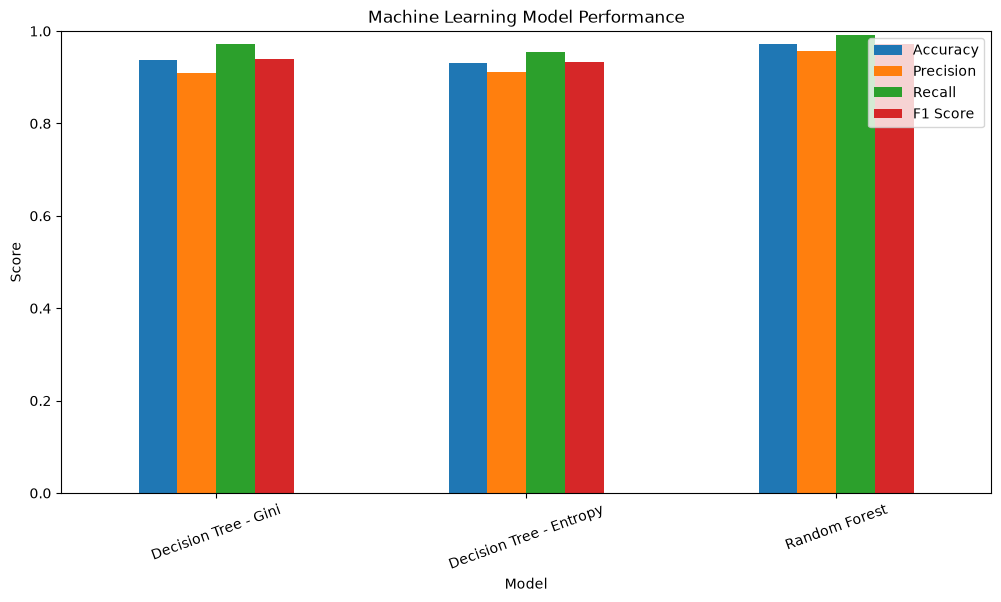

In [30]:
# ================================
# 30. MODEL PERFORMANCE GRAPH
# ================================

results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.legend()

plt.show()

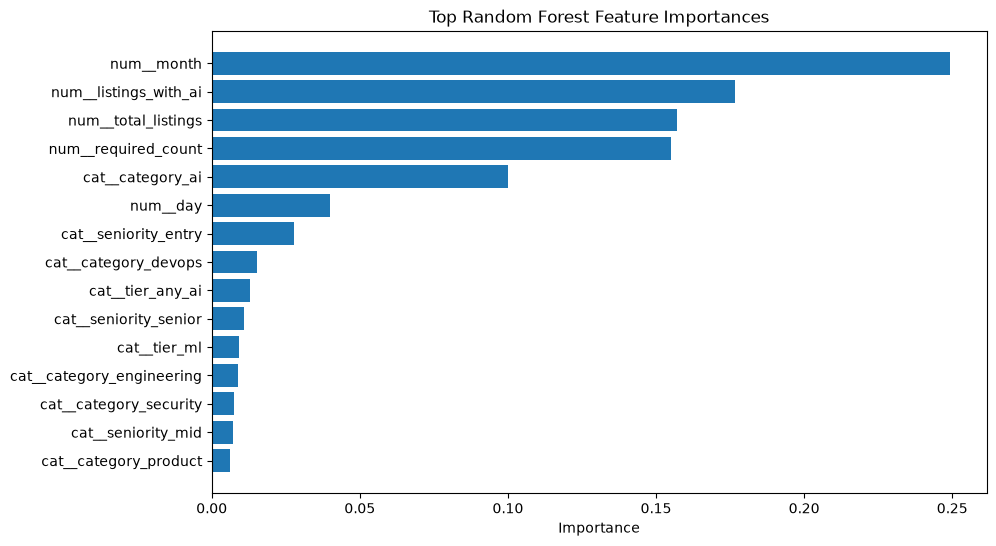

In [31]:
# ================================
# 31. RANDOM FOREST FEATURE IMPORTANCE
# ================================

rf_model = random_forest.named_steps["model"]

feature_names = (
    random_forest
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Random Forest Feature Importances")

plt.xlabel("Importance")

plt.show()